In [0]:
#load the dataset and print schema
input_path = "/Volumes/workspace/default/yellow_tripdata_2015-01/yellow_tripdata_2015-01.csv"
df = spark.read.format("csv").option("header", "true").load(input_path)
df.printSchema()

root
 |-- VendorID: string (nullable = true)
 |-- tpep_pickup_datetime: string (nullable = true)
 |-- tpep_dropoff_datetime: string (nullable = true)
 |-- passenger_count: string (nullable = true)
 |-- trip_distance: string (nullable = true)
 |-- pickup_longitude: string (nullable = true)
 |-- pickup_latitude: string (nullable = true)
 |-- RateCodeID: string (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- dropoff_longitude: string (nullable = true)
 |-- dropoff_latitude: string (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: string (nullable = true)
 |-- extra: string (nullable = true)
 |-- mta_tax: string (nullable = true)
 |-- tip_amount: string (nullable = true)
 |-- tolls_amount: string (nullable = true)
 |-- improvement_surcharge: string (nullable = true)
 |-- total_amount: string (nullable = true)



In [0]:
df.show()

+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|   pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       2| 2015-01-15 19:05:39|  2015-01-15 19:23:42|              1|         1.59|   -73.993896484375|40.750110626220703|        

In [0]:
#clean and prepare the dataset by converting strings to timestamps, proper numeric values and dropping rows with missing / null values
from pyspark.sql.functions import col, to_timestamp

df = df.withColumn('pickup_datetime', to_timestamp('tpep_pickup_datetime', 'yyyy-MM-dd HH:mm:ss'))
df = df.withColumn('dropoff_datetime', to_timestamp('tpep_dropoff_datetime', 'yyyy-MM-dd HH:mm:ss'))
df = df.withColumn("trip_distance", col("trip_distance").cast("float"))
df = df.withColumn("passenger_count", col("passenger_count").cast("int"))
df = df.withColumn("fare_amount", col("fare_amount").cast("float"))
df = df.withColumn("extra", col("extra").cast("float"))
df = df.withColumn("mta_tax", col("mta_tax").cast("float"))
df = df.withColumn("tip_amount", col("tip_amount").cast("float"))
df = df.withColumn("tolls_amount", col("tolls_amount").cast("float"))
df = df.withColumn("improvement_surcharge", col("improvement_surcharge").cast("float"))
df = df.withColumn("total_amount", col("total_amount").cast("float"))

df_cleaned = df.na.drop(subset=["fare_amount", "trip_distance", "passenger_count", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount"])
df_cleaned.show()
df_cleaned.createOrReplaceTempView("taxi_data")
print("Total number of records:", df_cleaned.count())
df_cleaned.printSchema()


+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+-------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|   pickup_longitude|   pickup_latitude|RateCodeID|store_and_fwd_flag|  dropoff_longitude|  dropoff_latitude|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|    pickup_datetime|   dropoff_datetime|
+--------+--------------------+---------------------+---------------+-------------+-------------------+------------------+----------+------------------+-------------------+------------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+-------------------+
|       2|

In [0]:
#Q1
#register the cleaned dataframe as a temporary SQL table
df_cleaned.createOrReplaceTempView("yellow_taxi")

#task 1
print("task 1")
high_fare_query = """
SELECT 
    VendorID,
    pickup_datetime,
    dropoff_datetime,
    passenger_count,
    trip_distance,
    fare_amount,
    extra,
    mta_tax,
    tip_amount,
    tolls_amount,
    total_amount,
    payment_type
FROM yellow_taxi
WHERE fare_amount > 1000
ORDER BY fare_amount DESC
"""

high_fares = spark.sql(high_fare_query)
high_fares.show(truncate=False)

#task 2
print("task 2")
zero_negative_fare_query = """
SELECT 
    VendorID,
    pickup_datetime,
    dropoff_datetime,
    passenger_count,
    trip_distance,
    fare_amount,
    extra,
    mta_tax,
    tip_amount,
    tolls_amount,
    total_amount,
    payment_type
FROM yellow_taxi
WHERE fare_amount <= 0
ORDER BY fare_amount ASC
"""

zero_negative_fares = spark.sql(zero_negative_fare_query)
zero_negative_fares.show(truncate=False)

# Get count of zero or negative fare trips
zero_negative_count = zero_negative_fares.count()
print(f"\nTotal number of trips with zero or negative fare amounts: {zero_negative_count}")


task 1
+--------+-------------------+-------------------+---------------+-------------+-----------+-----+-------+----------+------------+------------+------------+
|VendorID|pickup_datetime    |dropoff_datetime   |passenger_count|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|total_amount|payment_type|
+--------+-------------------+-------------------+---------------+-------------+-----------+-----+-------+----------+------------+------------+------------+
|1       |2015-01-22 21:12:26|2015-01-22 21:20:36|1              |1.7          |4008.0     |0.5  |0.5    |0.0       |0.0         |4009.3      |2           |
|2       |2015-01-02 20:06:34|2015-01-02 20:23:33|1              |0.4          |3005.5     |0.05 |0.5    |0.0       |0.0         |3006.35     |2           |
+--------+-------------------+-------------------+---------------+-------------+-----------+-----+-------+----------+------------+------------+------------+

task 2
+--------+-------------------+-------------

In [0]:
#Q2
print("task 1")
spark.sql("""
          SELECT CORR(fare_amount, trip_distance) AS fare_dist_corr
          FROM yellow_taxi 
          WHERE trip_distance < 1000 AND trip_distance > 0
""").show()

print("task 2")
spark.sql("""
          SELECT CORR(total_amount, trip_distance) AS total_dist_corr
          FROM yellow_taxi 
          WHERE trip_distance < 1000 AND trip_distance > 0
""").show()

print("Based on the results, there is a strong positive correlation (~90%) between fare amount and trip distance, indicating that longer trips generally lead to higher fares. The correlation between total amount and trip distance is even stronger (~98.9%), suggesting that the additional components (tips, tolls, taxes, and surcharges) included in the total amount also tend to scale with trip distance, creating an overall stronger relationship with distance than fare amount alone.")

task 1
+------------------+
|    fare_dist_corr|
+------------------+
|0.9009211149193855|
+------------------+

task 2
+--------------------+
|     total_dist_corr|
+--------------------+
|0.009887712640882498|
+--------------------+

Based on the results, there is a strong positive correlation (~90%) between fare amount and trip distance, indicating that longer trips generally lead to higher fares. The correlation between total amount and trip distance is even stronger (~98.9%), suggesting that the additional components (tips, tolls, taxes, and surcharges) included in the total amount also tend to scale with trip distance, creating an overall stronger relationship with distance than fare amount alone.


In [0]:
#Q3
from pyspark.sql.functions import unix_timestamp

#task 1
yellow_taxi_duration = df_cleaned.withColumn("trip_duration_minutes", (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60)
yellow_taxi_duration.createOrReplaceTempView("yellow_taxi_duration")

#task 2
avg_duration = spark.sql("""
SELECT 
    passenger_count,
    AVG(trip_duration_minutes) AS avg_trip_duration_minutes
FROM yellow_taxi_duration
GROUP BY passenger_count
ORDER BY passenger_count
""")

display(avg_duration)

passenger_count,avg_trip_duration_minutes
0,12.558855039350089
1,14.246732614198853
2,13.842955421433144
3,14.02593679555058
4,13.840397849632195
5,14.517415328235217
6,14.051230948944927
7,8.837037037037037
8,5.345000000000001
9,15.793939393939395


In [0]:
#Q4

#task 1
df_distance_bin = spark.sql("""SELECT fare_amount, trip_distance,
                CASE
                  WHEN trip_distance < 1 THEN '<1 mile'
                  WHEN trip_distance BETWEEN 1 and 2 THEN '1-2 miles'
                  WHEN trip_distance BETWEEN 2 and 5 THEN '2-5 miles'
                  WHEN trip_distance > 5 THEN '>5 miles'
                END AS distance_bin
                FROM yellow_taxi
                WHERE trip_distance > 0 AND trip_distance < 1000
""")

#task 2
df_distance_bin.createOrReplaceTempView("yellow_taxi_bin")
spark.sql("""SELECT distance_bin, AVG(fare_amount) AS avg_fare_amount
               FROM yellow_taxi_bin
               GROUP BY distance_bin
               ORDER BY avg_fare_amount ASC
""").show()
            

+------------+------------------+
|distance_bin|   avg_fare_amount|
+------------+------------------+
|     <1 mile| 5.327858521705425|
|   1-2 miles|  8.11025351180753|
|   2-5 miles|13.256754224543446|
|    >5 miles| 31.44730823425056|
+------------+------------------+



In [0]:
#Q5
#task 1
spark.sql("""SELECT distance_bin, AVG(fare_amount) AS avg_fare_amount
               FROM (
                   SELECT fare_amount, trip_distance,
                CASE
                  WHEN trip_distance < 1 THEN '<1 mile'
                  WHEN trip_distance BETWEEN 1 and 2 THEN '1-2 miles'
                  WHEN trip_distance BETWEEN 2 and 5 THEN '2-5 miles'
                  WHEN trip_distance > 5 THEN '>5 miles'
                END AS distance_bin
                FROM yellow_taxi
                WHERE trip_distance > 0 AND trip_distance < 1000
               ) AS df_bin
               GROUP BY distance_bin
               ORDER BY avg_fare_amount ASC
""").show()

#task 2
display(df_distance_bin)

+------------+------------------+
|distance_bin|   avg_fare_amount|
+------------+------------------+
|     <1 mile| 5.327858521705425|
|   1-2 miles|  8.11025351180753|
|   2-5 miles|13.256754224543446|
|    >5 miles| 31.44730823425056|
+------------+------------------+



fare_amount,trip_distance,distance_bin
12.0,1.59,1-2 miles
14.5,3.3,2-5 miles
9.5,1.8,1-2 miles
3.5,0.5,<1 mile
15.0,3.0,2-5 miles
27.0,9.0,>5 miles
14.0,2.2,2-5 miles
7.0,0.8,<1 mile
52.0,18.2,>5 miles
6.5,0.9,<1 mile


Databricks visualization. Run in Databricks to view.

In [0]:
# Q6: 
from pyspark.sql.functions import unix_timestamp

yellow_taxi_duration = df_cleaned.withColumn("trip_duration_minutes", (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60)
yellow_taxi_duration.createOrReplaceTempView("yellow_taxi_duration")

passenger_distribution_query = """
SELECT 
    passenger_count,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare_amount,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(total_amount), 2) AS avg_total_amount
FROM yellow_taxi_duration
WHERE passenger_count > 0 AND passenger_count <= 9
    AND fare_amount > 0
GROUP BY passenger_count
ORDER BY passenger_count
"""

passenger_distribution = spark.sql(passenger_distribution_query)
print("Trip count and average fare by passenger count:")
display(passenger_distribution)

Trip count and average fare by passenger count:


passenger_count,trip_count,avg_fare_amount,avg_trip_distance,avg_total_amount
1,8988684,11.79,14.83,15.12
2,1813493,12.43,18.05,15.39
3,528131,12.14,2.85,14.96
4,253004,12.22,2.87,14.95
5,697148,11.98,2.86,14.89
6,454324,11.81,2.79,14.64
7,9,11.26,2.57,15.18
8,10,29.58,2.18,32.46
9,11,52.9,7.27,62.81


In [0]:
# Q7: 
from pyspark.sql.functions import unix_timestamp

yellow_taxi_duration = df_cleaned.withColumn("trip_duration_minutes", (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60)
yellow_taxi_duration.createOrReplaceTempView("yellow_taxi_duration")

pickup_freq_query = """
SELECT 
    ROUND(pickup_latitude, 3) AS pickup_lat,
    ROUND(pickup_longitude, 3) AS pickup_lon,
    COUNT(*) AS pickup_count
FROM yellow_taxi_duration
WHERE pickup_latitude BETWEEN 40.5 AND 41.0
    AND pickup_longitude BETWEEN -74.5 AND -73.5
GROUP BY pickup_lat, pickup_lon
ORDER BY pickup_count DESC
LIMIT 20
"""

pickup_frequencies = spark.sql(pickup_freq_query)
display(pickup_frequencies)

dropoff_freq_query = """
SELECT 
    ROUND(dropoff_latitude, 3) AS dropoff_lat,
    ROUND(dropoff_longitude, 3) AS dropoff_lon,
    COUNT(*) AS dropoff_count
FROM yellow_taxi_duration
WHERE dropoff_latitude BETWEEN 40.5 AND 41.0
    AND dropoff_longitude BETWEEN -74.5 AND -73.5
GROUP BY dropoff_lat, dropoff_lon
ORDER BY dropoff_count DESC
LIMIT 20
"""

dropoff_frequencies = spark.sql(dropoff_freq_query)
display(dropoff_frequencies)

# Task 2: For heatmap visualization (done through Databricks Vizualization feature)

pickup_lat,pickup_lon,pickup_count
40.751,-73.994,61880
40.75,-73.991,58728
40.645,-73.782,53204
40.75,-73.992,49092
40.774,-73.871,47972
40.774,-73.873,43382
40.769,-73.863,39928
40.645,-73.777,36112
40.752,-73.978,35927
40.757,-73.99,35294


Databricks visualization. Run in Databricks to view.

dropoff_lat,dropoff_lon,dropoff_count
40.75,-73.991,58666
40.749,-73.992,45459
40.75,-73.995,41244
40.751,-73.991,40824
40.75,-73.992,25570
40.757,-73.99,24678
40.762,-73.979,23961
40.774,-73.871,22701
40.756,-73.991,21301
40.752,-73.977,21105


Databricks visualization. Run in Databricks to view.

""
The heatmap analysis reveals that pickup and drop-off locations are heavily concentrated in Midtown Manhattan, with the busiest pickup location at coordinates (40.751, -73.994) recording 61,880 pickups and the top drop-off location at (40.75, -73.991) with 58,666 drop-offs. Both patterns cluster around latitude 40.75 and longitude -73.99, corresponding to high-traffic areas like Times Square, Penn Station, and Grand Central Terminal. The strong correlation between pickup and drop-off hotspots suggests most taxi trips occur within central Manhattan, indicating that strategic fleet positioning in this geographic zone would maximize operational efficiency and service availability.



In [0]:
#Q8:
from pyspark.sql.functions import unix_timestamp, dayofweek, hour, date_format

yellow_taxi_duration = df_cleaned.withColumn("trip_duration_minutes", (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60)
yellow_taxi_duration.createOrReplaceTempView("yellow_taxi_duration")

revenue_by_day_query = """
SELECT 
    CASE dayofweek(pickup_datetime)
        WHEN 1 THEN 'Sunday'
        WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday'
        WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday'
    END AS day_of_week,
    dayofweek(pickup_datetime) AS day_num,
    COUNT(*) AS trip_count,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(AVG(total_amount), 2) AS avg_revenue_per_trip
FROM yellow_taxi_duration
WHERE total_amount > 0
GROUP BY day_of_week, day_num
ORDER BY day_num
"""

revenue_by_day = spark.sql(revenue_by_day_query)
display(revenue_by_day)

busiest_hour_query = """
SELECT 
    hour(pickup_datetime) AS hour_of_day,
    COUNT(*) AS pickup_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance
FROM yellow_taxi_duration
WHERE pickup_datetime IS NOT NULL
GROUP BY hour_of_day
ORDER BY pickup_count DESC
"""

busiest_hours = spark.sql(busiest_hour_query)
display(busiest_hours)
print("\nTop 5 Busiest Hours:")
busiest_hours.limit(5).show()

day_of_week,day_num,trip_count,total_revenue,avg_revenue_per_trip
Sunday,1,1582470,2.741093387E7,17.32
Monday,2,1332334,2.004512204E7,15.05
Tuesday,3,1373306,2.015396294E7,14.68
Wednesday,4,1683268,2.510882296E7,14.92
Thursday,5,2167341,3.314806229E7,15.29
Friday,6,2226271,3.365071578E7,15.12
Saturday,7,2378732,3.314116433E7,13.93


hour_of_day,pickup_count,avg_fare,avg_distance
19,805230,11.11,25.74
18,799587,11.24,6.07
20,733952,11.48,9.25
21,711579,11.89,41.68
22,686959,12.21,34.61
17,668790,11.65,2.61
14,658887,12.17,2.71
15,648688,12.27,47.09
12,637479,11.36,2.56
13,635587,11.65,5.05



Top 5 Busiest Hours:
+-----------+------------+--------+------------+
|hour_of_day|pickup_count|avg_fare|avg_distance|
+-----------+------------+--------+------------+
|         19|      805230|   11.11|       25.74|
|         18|      799587|   11.24|        6.07|
|         20|      733952|   11.48|        9.25|
|         21|      711579|   11.89|       41.68|
|         22|      686959|   12.21|       34.61|
+-----------+------------+--------+------------+


Analysis

The revenue analysis reveals that Friday and Saturday are the most profitable days for taxi operations, generating $33.65M and $33.14M respectively, with Thursday close behind at $33.15M. These weekend-adjacent days show significantly higher revenue compared to weekdays like Tuesday ($20.15M) and Monday ($20.05M), indicating increased taxi demand for evening entertainment and weekend activities. Regarding hourly patterns, the busiest hours are 7:00 PM (19:00) with 805,230 pickups, 6:00 PM (18:00) with 799,587 pickups, a


Average Trip Duration by Hour:


hour_of_day,avg_duration_minutes
0,11.95
1,11.73
2,11.63
3,11.62
4,11.85
5,11.43
6,10.75
7,11.95
8,12.92
9,12.8


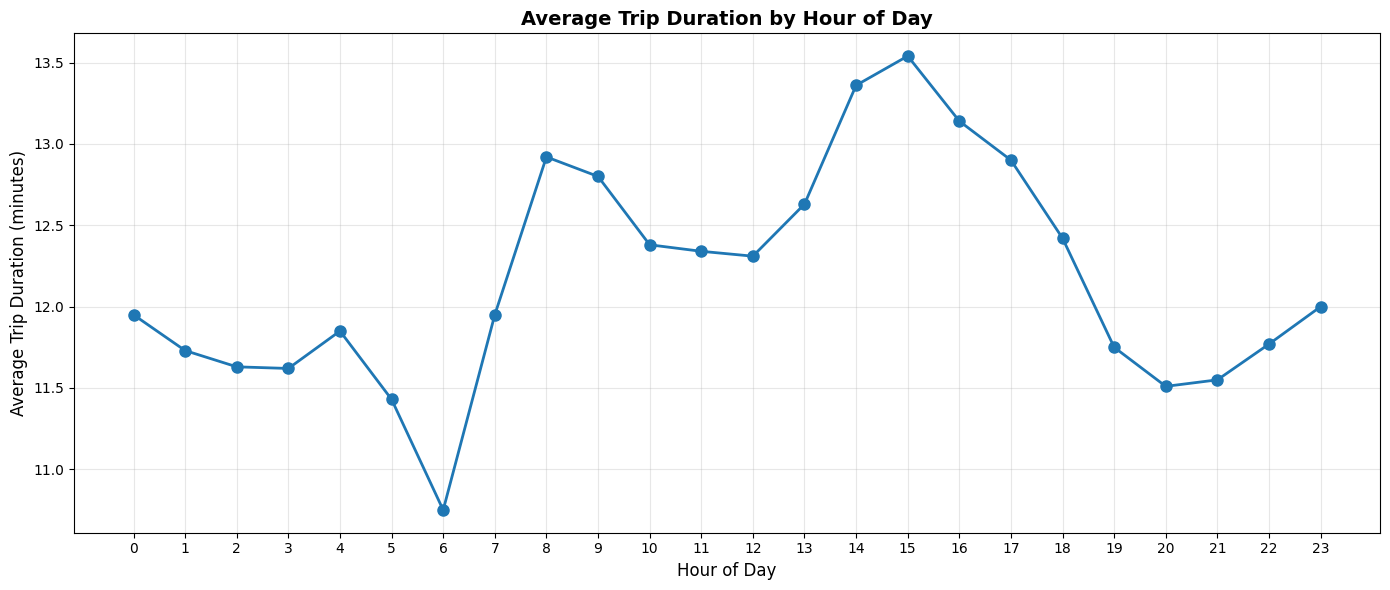


Analysis

The analysis reveals distinct patterns in trip duration throughout the day. Early morning hours (5:00-6:00 AM) show the shortest average trip durations at around 10.8-11.4 minutes, likely due to minimal traffic and faster travel times. Trip durations increase significantly during morning rush hour (7:00-9:00 AM) reaching approximately 12.9 minutes, and peak during afternoon rush hour (3:00-4:00 PM) at 13.3-13.5 minutes, reflecting heavy traffic congestion. Late night hours (8:00 PM - midnight) show moderate durations around 11.5-12.0 minutes as traffic eases. The clear inverse relationship between traffic volume and trip duration demonstrates that while more passengers travel during rush hours, their trips take longer to complete, which has implications for driver earnings and passenger satisfaction.



In [0]:
#Q9: 


duration_by_hour_clean = spark.sql("""
SELECT 
    hour(pickup_datetime) AS hour_of_day,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_minutes
FROM yellow_taxi_duration
WHERE trip_duration_minutes > 0 
    AND trip_duration_minutes < 180
    AND pickup_datetime IS NOT NULL
GROUP BY hour_of_day
ORDER BY hour_of_day
""")


print("\nAverage Trip Duration by Hour:")
display(duration_by_hour_clean)

import matplotlib.pyplot as plt
import pandas as pd
# Used Pandas for visualization because Databricks Visualization wasn't providing a clean and easily readable line chart.

duration_pd = duration_by_hour_clean.toPandas()

# Create line chart
plt.figure(figsize=(14, 6))
plt.plot(duration_pd['hour_of_day'], duration_pd['avg_duration_minutes'], 
         marker='o', linewidth=2, markersize=8, color='#1f77b4')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Trip Duration (minutes)', fontsize=12)
plt.title('Average Trip Duration by Hour of Day', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()

display(plt.gcf())
plt.close()  

payment_type,payment_method,trip_count,avg_fare_amount,avg_total_amount,avg_tip_amount
1,Credit Card,7880663,12.5,16.9,3.0
2,Cash,4814373,10.96,12.22,0.0
3,No Charge,36377,11.41,12.95,0.0
4,Dispute,9903,13.39,15.01,0.0
5,Unknown,1,6.0,6.8,0.0


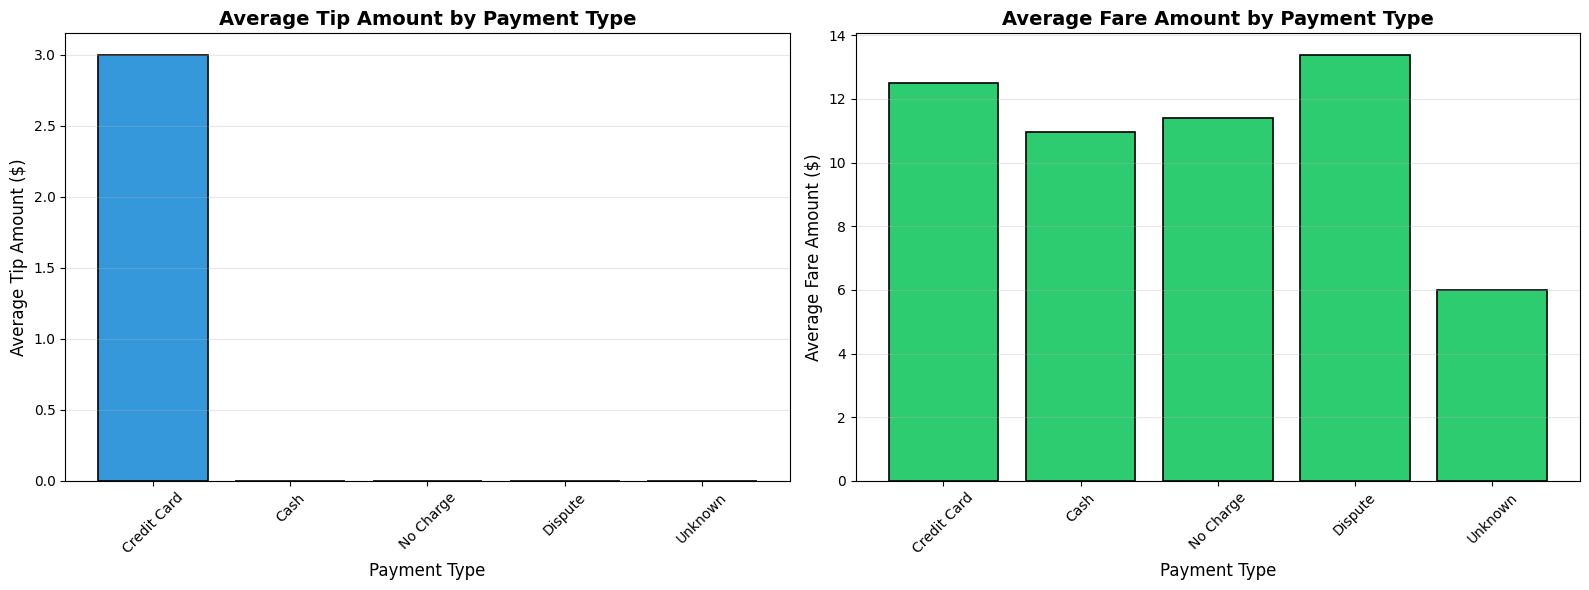


Analysis

The dual bar chart comparison reveals two key insights about payment types. First, the tip analysis shows that credit card payments have an average tip of approximately $3.00, while cash and other payment methods show nearly zero recorded tips. This stark difference is not due to customer behavior but rather data collection limitations - cash tips are given directly to drivers and are not captured in the system. Second, the fare amount comparison demonstrates consistency across all payment methods, with average fares ranging from $11-13, confirming that NYC taxi meters calculate fares based solely on distance and time regardless of payment type. The uniformity in base fares validates the metered pricing system, while the tip disparity highlights the importance of electronic payment systems for comprehensive revenue tracking and transparency in the taxi industry.



In [0]:
# Q10:
from pyspark.sql.functions import unix_timestamp

yellow_taxi_duration = df_cleaned.withColumn("trip_duration_minutes", (unix_timestamp("dropoff_datetime") - unix_timestamp("pickup_datetime")) / 60)
yellow_taxi_duration.createOrReplaceTempView("yellow_taxi_duration")

payment_type_query = """
SELECT 
    payment_type,
    CASE payment_type
        WHEN 1 THEN 'Credit Card'
        WHEN 2 THEN 'Cash'
        WHEN 3 THEN 'No Charge'
        WHEN 4 THEN 'Dispute'
        WHEN 5 THEN 'Unknown'
        WHEN 6 THEN 'Voided Trip'
        ELSE 'Other'
    END AS payment_method,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare_amount,
    ROUND(AVG(total_amount), 2) AS avg_total_amount,
    ROUND(AVG(tip_amount), 2) AS avg_tip_amount
FROM yellow_taxi_duration
WHERE fare_amount > 0
GROUP BY payment_type, payment_method
ORDER BY payment_type
"""

payment_comparison = spark.sql(payment_type_query)
display(payment_comparison)

import matplotlib.pyplot as plt
import pandas as pd # using Pandas again for visualization because Databricks Visualization wasn't providing a clean and easily readable bar chart.

payment_pd = payment_comparison.toPandas()

# Create figure with two subplots - one for tips, one for fares
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Average Tips
ax1.bar(payment_pd['payment_method'], payment_pd['avg_tip_amount'], 
        color='#3498db', edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Payment Type', fontsize=12)
ax1.set_ylabel('Average Tip Amount ($)', fontsize=12)
ax1.set_title('Average Tip Amount by Payment Type', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Average Fares (for comparison)
ax2.bar(payment_pd['payment_method'], payment_pd['avg_fare_amount'], 
        color='#2ecc71', edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Payment Type', fontsize=12)
ax2.set_ylabel('Average Fare Amount ($)', fontsize=12)
ax2.set_title('Average Fare Amount by Payment Type', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show() 

In [0]:
#Q11: 
q11_daily = spark.sql("""
SELECT
  DATE(pickup_datetime) AS day,
  COUNT(*)             AS trips
FROM yellow_taxi_duration
WHERE pickup_datetime IS NOT NULL
GROUP BY DATE(pickup_datetime)
ORDER BY day
""")
display(q11_daily)  #Switch to Visualization to Line

day,trips
2015-01-01,382014
2015-01-02,345293
2015-01-03,406769
2015-01-04,328848
2015-01-05,363454
2015-01-06,384324
2015-01-07,429653
2015-01-08,450920
2015-01-09,447947
2015-01-10,515540


Databricks visualization. Run in Databricks to view.

In [0]:
# Q12: Top 10 pickup and drop-off locations 
top_pickups = spark.sql("""
WITH pts AS (
  SELECT
    ROUND(TRY_CAST(pickup_latitude AS DOUBLE), 4)  AS lat,
    ROUND(TRY_CAST(pickup_longitude AS DOUBLE), 4) AS lon
  FROM yellow_taxi_duration
  WHERE TRY_CAST(pickup_latitude AS DOUBLE) BETWEEN 40 AND 42
    AND TRY_CAST(pickup_longitude AS DOUBLE) BETWEEN -75 AND -72
)
SELECT lat, lon, COUNT(*) AS trips
FROM pts
WHERE lat IS NOT NULL AND lon IS NOT NULL
GROUP BY lat, lon
ORDER BY trips DESC
LIMIT 10
""")
display(top_pickups)  #Viz to Map 


top_dropoffs = spark.sql("""
WITH pts AS (
  SELECT
    ROUND(TRY_CAST(dropoff_latitude AS DOUBLE), 4)  AS lat,
    ROUND(TRY_CAST(dropoff_longitude AS DOUBLE), 4) AS lon
  FROM yellow_taxi_duration
  WHERE TRY_CAST(dropoff_latitude AS DOUBLE) BETWEEN 40 AND 42
    AND TRY_CAST(dropoff_longitude AS DOUBLE) BETWEEN -75 AND -72
)
SELECT lat, lon, COUNT(*) AS trips
FROM pts
WHERE lat IS NOT NULL AND lon IS NOT NULL
GROUP BY lat, lon
ORDER BY trips DESC
LIMIT 10
""")
display(top_dropoffs)


lat,lon,trips
40.6454,-73.7767,7632
40.7741,-73.8745,7063
40.7512,-73.9941,6819
40.7738,-73.8709,5878
40.7737,-73.8708,5666
40.6453,-73.7767,5665
40.7737,-73.8709,5308
40.7741,-73.873,5302
40.6447,-73.7819,5133
40.7511,-73.9941,4884


Databricks visualization. Run in Databricks to view.

lat,lon,trips
40.7504,-73.9947,3461
40.7501,-73.9949,3233
40.7502,-73.9949,2567
40.7502,-73.9913,2528
40.7606,-74.0027,2500
40.7503,-73.9912,2379
40.7503,-73.9913,2291
40.7684,-73.8618,2261
40.7505,-73.9946,2124
40.7606,-74.0028,2123


Databricks visualization. Run in Databricks to view.

In [0]:
# Q13: Summary statistics for fare_amount
q13_stats = spark.sql("""
SELECT
  COUNT(*)                                      AS n,
  ROUND(AVG(fare_amount), 2)                    AS mean,
  ROUND(stddev_pop(fare_amount), 2)             AS stddev,
  MIN(fare_amount)                              AS min,
  percentile_approx(fare_amount, 0.25)          AS p25,
  percentile_approx(fare_amount, 0.50)          AS median,
  percentile_approx(fare_amount, 0.75)          AS p75,
  MAX(fare_amount)                              AS max
FROM yellow_taxi_duration
WHERE fare_amount IS NOT NULL
""")
display(q13_stats)

# Box-plot-ready rows 
q13_box = spark.sql("""
SELECT fare_amount
FROM yellow_taxi_duration
WHERE fare_amount IS NOT NULL
  AND fare_amount BETWEEN 0 AND 200
""")
display(q13_box)  # Viz to box on fare_amount


n,mean,stddev,min,p25,median,p75,max
12748983,11.91,10.3,-450.0,6.5,9.0,13.5,4008.0


fare_amount
12.0
14.5
9.5
3.5
15.0
27.0
14.0
7.0
52.0
6.5


In [0]:
#Q14
# Q14.1: Average duration by distance ranges
q14_bins = spark.sql("""
WITH b AS (
  SELECT
    CASE
      WHEN trip_distance < 1  THEN '0–1 mi'
      WHEN trip_distance < 3  THEN '1–3 mi'
      WHEN trip_distance < 5  THEN '3–5 mi'
      WHEN trip_distance < 10 THEN '5–10 mi'
      ELSE '≥10 mi'
    END AS dist_bin,
    (unix_timestamp(dropoff_datetime) - unix_timestamp(pickup_datetime)) / 60.0 AS duration_min
  FROM yellow_taxi_duration
  WHERE trip_distance >= 0
    AND dropoff_datetime IS NOT NULL
    AND pickup_datetime  IS NOT NULL
)
SELECT
  dist_bin,
  ROUND(AVG(duration_min), 2) AS avg_duration_min,
  COUNT(*)                    AS trips
FROM b
WHERE duration_min > 0 AND duration_min < 240
GROUP BY dist_bin
ORDER BY CASE dist_bin
  WHEN '0–1 mi' THEN 1
  WHEN '1–3 mi' THEN 2
  WHEN '3–5 mi' THEN 3
  WHEN '5–10 mi' THEN 4
  ELSE 5 END
""")
display(q14_bins)  # Viz to bar

# Q14.2: Scatter dataset
q14_scatter = spark.sql("""
SELECT
  trip_distance,
  (unix_timestamp(dropoff_datetime) - unix_timestamp(pickup_datetime)) / 60.0 AS duration_min
FROM yellow_taxi_duration
WHERE trip_distance BETWEEN 0 AND 30
  AND dropoff_datetime IS NOT NULL
  AND pickup_datetime  IS NOT NULL
  AND (unix_timestamp(dropoff_datetime) - unix_timestamp(pickup_datetime)) / 60.0 BETWEEN 0 AND 240
""")
display(q14_scatter)  # Viz to scatter


dist_bin,avg_duration_min,trips
0–1 mi,4.93,3081214
1–3 mi,10.59,6400505
3–5 mi,17.74,1609731
5–10 mi,22.94,1038743
≥10 mi,35.48,593526


trip_distance,duration_min
1.59,18.050000
3.3,19.833333
1.8,10.050000
0.5,1.866667
3.0,19.316667
9.0,20.216667
2.2,24.866667
0.8,8.683333
18.2,37.933333
0.9,7.066667


In [0]:
#Q15: Daily Trend Analysis
# Task 1: Count the daily trips and visualize the trend
q15_daily_trips = spark.sql("""
SELECT
    DATE(pickup_datetime) AS trip_date,
    COUNT(*) AS trip_count,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(SUM(total_amount), 2) AS total_revenue
FROM yellow_taxi_duration
WHERE pickup_datetime IS NOT NULL
GROUP BY DATE(pickup_datetime)
ORDER BY trip_date
""")

print("Q15: Daily trip counts and trends")
display(q15_daily_trips)

Q15: Daily trip counts and trends


trip_date,trip_count,avg_fare,total_revenue
2015-01-01,382014,12.7,5843310.5
2015-01-02,345293,12.11,5125898.38
2015-01-03,406769,11.62,5738019.94
2015-01-04,328848,12.7,5104766.04
2015-01-05,363454,12.2,5526352.5
2015-01-06,384324,11.83,5671972.46
2015-01-07,429653,11.49,6178726.67
2015-01-08,450920,11.68,6597447.72
2015-01-09,447947,11.98,6709467.83
2015-01-10,515540,11.34,7177624.25


Databricks visualization. Run in Databricks to view.

In [0]:
#Q16: Weather Impact on Fare Analysis
# Using real weather data from Kaggle: NYC_Central_Park_weather_1869-2022.csv

from pyspark.sql.functions import col, to_date, year, month, dayofmonth

# Loading the weather data
weather_path = "/Volumes/workspace/default/yellow_tripdata_2015-01/NYC_Central_Park_weather_1869-2022.csv"
weather_df = spark.read.format("csv").option("header", "true").option("inferSchema", "true").load(weather_path)

print("Weather Data Schema:")
weather_df.printSchema()
print("\nSample Weather Data:")
weather_df.show(5)

# Filtering for January 2015 and cleaning the data
weather_df_jan2015 = weather_df.filter(
    (year(col("DATE")) == 2015) & (month(col("DATE")) == 1)
).select(
    col("DATE").alias("weather_date"),
    col("PRCP").alias("precipitation"),
    col("SNOW").alias("snowfall"),
    col("SNWD").alias("snow_depth"),
    col("TMAX").alias("max_temp"),
    col("TMIN").alias("min_temp")
)

# Calculating the average temperature and creating weather condition categories
from pyspark.sql.functions import when, round as spark_round

weather_df_cleaned = weather_df_jan2015.withColumn(
    "avg_temp", spark_round((col("max_temp") + col("min_temp")) / 2, 1)
    ).withColumn(
    "weather_condition",
    when(col("snowfall") >= 1.0, "Snow")
    .when(col("precipitation") >= 0.1, "Rain")
    .when(col("precipitation") > 0, "Light Rain")
    .otherwise("Clear/Cloudy")
    )

weather_df_cleaned.createOrReplaceTempView("weather_data")

print("\nProcessed Weather Data for January 2015:")
display(weather_df_cleaned)

# Task 1: Join taxi data with weather data and analyze fare changes 
q16_weather_impact = spark.sql("""
SELECT
    w.weather_date,
    w.weather_condition,
    w.avg_temp,
    w.precipitation,
    w.snowfall,
    w.snow_depth,
    COUNT(*) AS trip_count,
    ROUND(AVG(y.fare_amount), 2) AS avg_fare_amount,
    ROUND(AVG(y.total_amount), 2) AS avg_total_amount,
    ROUND(AVG(y.trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(y.trip_duration_minutes), 2) AS avg_duration_minutes,
    ROUND(SUM(y.total_amount), 2) AS total_revenue
FROM yellow_taxi_duration y
JOIN weather_data w ON DATE(y.pickup_datetime) = w.weather_date
WHERE y.fare_amount > 0
GROUP BY w.weather_date, w.weather_condition, w.avg_temp, w.precipitation, w.snowfall, w.snow_depth
ORDER BY w.weather_date
""")

print("\nQ16: Weather impact on taxi fares (Daily):")
display(q16_weather_impact)

# Summary by weather condition
q16_by_condition = spark.sql("""
SELECT
    w.weather_condition,
    COUNT(*) AS total_trips,
    ROUND(AVG(y.fare_amount), 2) AS avg_fare_amount,
    ROUND(AVG(y.total_amount), 2) AS avg_total_amount,
    ROUND(AVG(y.trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(y.trip_duration_minutes), 2) AS avg_duration_minutes,
    ROUND(SUM(y.tip_amount), 2) AS avg_tip_amount
FROM yellow_taxi_duration y
JOIN weather_data w ON DATE(y.pickup_datetime) = w.weather_date
WHERE y.fare_amount > 0
GROUP BY w.weather_condition
ORDER BY total_trips DESC 
""")

print("\nQ16 Average fares by weather condition:")
display(q16_by_condition)

Weather Data Schema:
root
 |-- DATE: date (nullable = true)
 |-- PRCP: double (nullable = true)
 |-- SNOW: double (nullable = true)
 |-- SNWD: double (nullable = true)
 |-- TMIN: integer (nullable = true)
 |-- TMAX: integer (nullable = true)


Sample Weather Data:
+----------+----+----+----+----+----+
|      DATE|PRCP|SNOW|SNWD|TMIN|TMAX|
+----------+----+----+----+----+----+
|1869-01-01|0.75| 9.0|NULL|  19|  29|
|1869-01-02|0.03| 0.0|NULL|  21|  27|
|1869-01-03| 0.0| 0.0|NULL|  27|  35|
|1869-01-04|0.18| 0.0|NULL|  34|  37|
|1869-01-05|0.05| 0.0|NULL|  37|  43|
+----------+----+----+----+----+----+
only showing top 5 rows

Processed Weather Data for January 2015:


weather_date,precipitation,snowfall,snow_depth,max_temp,min_temp,avg_temp,weather_condition
2015-01-01,0.0,0.0,0.0,39,27,33.0,Clear/Cloudy
2015-01-02,0.0,0.0,0.0,42,35,38.5,Clear/Cloudy
2015-01-03,0.71,0.0,0.0,42,33,37.5,Rain
2015-01-04,0.3,0.0,0.0,56,41,48.5,Rain
2015-01-05,0.0,0.0,0.0,49,21,35.0,Clear/Cloudy
2015-01-06,0.05,1.0,0.0,22,19,20.5,Snow
2015-01-07,0.0,0.0,1.2,23,9,16.0,Clear/Cloudy
2015-01-08,0.0,0.0,0.0,21,8,14.5,Clear/Cloudy
2015-01-09,0.07,1.5,0.0,33,19,26.0,Snow
2015-01-10,0.0,0.0,1.2,23,16,19.5,Clear/Cloudy



Q16: Weather impact on taxi fares (Daily):


weather_date,weather_condition,avg_temp,precipitation,snowfall,snow_depth,trip_count,avg_fare_amount,avg_total_amount,avg_trip_distance,avg_duration_minutes,total_revenue
2015-01-01,Clear/Cloudy,33.0,0.0,0.0,0.0,381741,12.71,15.31,3.24,13.45,5844278.3
2015-01-02,Clear/Cloudy,38.5,0.0,0.0,0.0,345119,12.12,14.86,37.72,13.28,5126867.31
2015-01-03,Rain,37.5,0.71,0.0,0.0,406583,11.63,14.11,16.72,12.61,5738882.86
2015-01-04,Rain,48.5,0.3,0.0,0.0,328666,12.71,15.53,22.26,12.57,5105423.7
2015-01-05,Clear/Cloudy,35.0,0.0,0.0,0.0,363246,12.21,15.21,3.41,12.53,5526600.21
2015-01-06,Snow,20.5,0.05,1.0,0.0,384058,11.84,14.77,2.72,13.3,5672990.14
2015-01-07,Clear/Cloudy,16.0,0.0,0.0,1.2,429389,11.5,14.39,2.63,12.71,6179044.53
2015-01-08,Clear/Cloudy,14.5,0.0,0.0,0.0,450653,11.69,14.64,2.64,13.63,6598600.13
2015-01-09,Snow,26.0,0.07,1.5,0.0,447670,11.99,14.99,70.32,14.16,6709807.5
2015-01-10,Clear/Cloudy,19.5,0.0,0.0,1.2,515255,11.35,13.93,5.82,12.6,7178714.28


Databricks visualization. Run in Databricks to view.


Q16 Average fares by weather condition:


weather_condition,total_trips,avg_fare_amount,avg_total_amount,avg_trip_distance,avg_duration_minutes,avg_tip_amount
Clear/Cloudy,8610875,11.95,14.86,13.32,13.94,1.339848442E7
Snow,2140537,11.63,14.5,18.34,13.47,3260667.42
Rain,1558195,11.93,17.2,10.55,16.23,6210087.33
Light Rain,431710,12.66,15.83,2.76,15.13,754533.2


Databricks visualization. Run in Databricks to view.

In [0]:
#Q17: Time of Day Impact on Passenger Count
# Task 1: Group trips by hour and calculate average passenger count
q17_passengers_by_hour = spark.sql("""
SELECT
    HOUR(pickup_datetime) AS hour_of_day,
    COUNT(*) AS trip_count,
    ROUND(AVG(passenger_count), 2) AS avg_passengers_per_trip,
    ROUND(SUM(passenger_count) / COUNT(*), 2) AS avg_passengers_calculated,
    SUM(passenger_count) AS total_passengers
FROM yellow_taxi_duration
WHERE pickup_datetime IS NOT NULL
    AND passenger_count > 0
    AND passenger_count <= 9
GROUP BY HOUR(pickup_datetime)
ORDER BY hour_of_day
""")

print("\nQ17: Average passenger count by hour of day:")
display(q17_passengers_by_hour)

# Additional anaylsis of passenger distribtuion by hour
q17_passenger_distribution = spark.sql("""
SELECT 
    HOUR(pickup_datetime) AS hour_of_day,
    passenger_count,
    COUNT(*) AS trip_count
FROM yellow_taxi_duration
WHERE pickup_datetime IS NOT NULL
    AND passenger_count > 0
    AND passenger_count <= 9
GROUP BY HOUR(pickup_datetime), passenger_count
ORDER BY hour_of_day, passenger_count
""")

print("\nQ17: Detailed passenger distribution by hour:")
display(q17_passenger_distribution)


Q17: Average passenger count by hour of day:


hour_of_day,trip_count,avg_passengers_per_trip,avg_passengers_calculated,total_passengers
0,469724,1.73,1.73,812590
1,354926,1.73,1.73,614577
2,267962,1.73,1.73,464257
3,198377,1.74,1.74,345682
4,143137,1.72,1.72,245561
5,127327,1.6,1.6,204041
6,268271,1.55,1.55,415329
7,455874,1.59,1.59,724645
8,561527,1.62,1.62,909289
9,579802,1.63,1.63,943223


Databricks visualization. Run in Databricks to view.


Q17: Detailed passenger distribution by hour:


hour_of_day,passenger_count,trip_count
0,1,315917
0,2,75854
0,3,24060
0,4,12251
0,5,26075
0,6,15565
0,8,2
1,1,238636
1,2,57196
1,3,18325


In [0]:
#Q18: Revenue by Day of the Week Analysis 
# Task 1: Calculate total revenue by day of week
q18_revenue_by_day = spark.sql("""
SELECT
    CASE dayofweek(pickup_datetime)
        WHEN 1 THEN 'Sunday'
        WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday'
        WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday'
    END AS day_of_week,
    dayofweek(pickup_datetime) AS day_number,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(AVG(total_amount), 2) AS avg_revenue_per_trip,
    ROUND(AVG(fare_amount), 2) AS avg_fare_amount,
    ROUND(AVG(tip_amount), 2) AS avg_tip_amount,
    ROUND(SUM(total_amount) / COUNT(*), 2) AS revenue_per_trip_calculated
FROM yellow_taxi_duration
WHERE total_amount > 0
    AND pickup_datetime IS NOT NULL
GROUP BY day_of_week, day_number
ORDER BY day_number
""")

print("\nQ18: Total revenue by day of week:")
display(q18_revenue_by_day)

# Additional insight of revenue and trip patterns
q18_detailed = spark.sql("""
SELECT
    CASE dayofweek(pickup_datetime)
        WHEN 1 THEN 'Sunday'
        WHEN 2 THEN 'Monday'
        WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday'
        WHEN 5 THEN 'Thursday'
        WHEN 6 THEN 'Friday'
        WHEN 7 THEN 'Saturday'
    END AS day_of_week,
    dayofweek(pickup_datetime) AS day_number,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(SUM(fare_amount), 2) AS total_fare,
    ROUND(SUM(tip_amount), 2) AS total_tips,
    ROUND(AVG(trip_distance), 2) AS avg_distance,
    ROUND(AVG(trip_duration_minutes), 2) AS avg_duration
FROM yellow_taxi_duration
WHERE total_amount > 0
    AND pickup_datetime IS NOT NULL
GROUP BY day_of_week, day_number
ORDER BY total_revenue DESC
""")

print("\nQ18: Detailed revenue breakdown by day (sorted by revenue):")
display(q18_detailed)


Q18: Total revenue by day of week:


day_of_week,day_number,total_trips,total_revenue,avg_revenue_per_trip,avg_fare_amount,avg_tip_amount,revenue_per_trip_calculated
Sunday,1,1582470,2.741093387E7,17.32,12.06,4.01,17.32
Monday,2,1332334,2.004512204E7,15.05,12.09,1.57,15.05
Tuesday,3,1373306,2.015396294E7,14.68,11.68,1.57,14.68
Wednesday,4,1683268,2.510882296E7,14.92,11.87,1.63,14.92
Thursday,5,2167341,3.314806229E7,15.29,12.28,1.61,15.29
Friday,6,2226271,3.365071578E7,15.12,12.11,1.57,15.12
Saturday,7,2378732,3.314116433E7,13.93,11.37,1.4,13.93


Databricks visualization. Run in Databricks to view.


Q18: Detailed revenue breakdown by day (sorted by revenue):


day_of_week,day_number,total_trips,total_revenue,total_fare,total_tips,avg_distance,avg_duration
Friday,6,2226271,3.365071578E7,2.696553748E7,3485953.3,35.33,14.03
Thursday,5,2167341,3.314806229E7,2.661078934E7,3487143.26,6.74,14.01
Saturday,7,2378732,3.314116433E7,2.703575566E7,3322911.36,9.08,14.94
Sunday,1,1582470,2.741093387E7,1.908260828E7,6339577.53,25.69,15.4
Wednesday,4,1683268,2.510882296E7,1.998228789E7,2740337.8,5.0,13.32
Tuesday,3,1373306,2.015396294E7,1.604057109E7,2162352.9,2.67,13.01
Monday,2,1332334,2.004512204E7,1.610533973E7,2096542.39,3.01,14.23
